<a href="https://colab.research.google.com/github/sohambaneerjee-17/utkface_generator/blob/main/utkface_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datasets import load_dataset

ds = load_dataset("nu-delta/utkface")

README.md:   0%|          | 0.00/467 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  343MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  343MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  362MB            

data/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/23705 [00:00<?, ? examples/s]

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Actual training device:", device)


PyTorch: 2.11.0+cu128
CUDA available: True
Actual training device: cuda


In [ ]:
test_dataset = ds["train"].select(range(100))

print("Images selected:", len(test_dataset))

Images selected: 100


In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms

# 1. Define transformations (resize to 64x64 and normalize to [-1, 1] for GANs)
transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)


# 2. Apply transform to your 100-image subset
class ProcessedUTKFace(torch.utils.data.Dataset):

  def __init__(self, hf_subset, transform=None):
    self.subset = hf_subset
    self.transform = transform

  def __len__(self):
    return len(self.subset)

  def __getitem__(self, idx):
    item = self.subset[idx]
    image = item["image"].convert("RGB")
    if self.transform:
      image = self.transform(image)
    return image


train_data = ProcessedUTKFace(test_dataset, transform=transform)
dataloader = DataLoader(train_data, batch_size=16, shuffle=True)

# Quick check to make sure a batch loads properly
images = next(iter(dataloader))
print("Batch shape:", images.shape)  # Should be torch.Size([16, 3, 64, 64])

Batch shape: torch.Size([16, 3, 64, 64])


In [ ]:
import torch.nn as nn


# --- 1. THE GENERATOR ---
class Generator(nn.Module):

  def __init__(self, latent_dim=100):
    super(Generator, self).__init__()
    # Takes random noise vector of size 100 and upscales it via convolutions
    self.main = nn.Sequential(
        # Input: latent_dim x 1 x 1
        nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(True),
        # State: 512 x 4 x 4
        nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(True),
        # State: 256 x 8 x 8
        nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(True),
        # State: 128 x 16 x 16
        nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(True),
        # State: 64 x 32 x 32
        nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
        nn.Tanh(),
        # Output: 3 x 64 x 64
    )

  def forward(self, input):
    return self.main(input)


# --- 2. THE DISCRIMINATOR ---
class Discriminator(nn.Module):

  def __init__(self):
    super(Discriminator, self).__init__()
    self.main = nn.Sequential(
        # Input: 3 x 64 x 64
        nn.Conv2d(3, 64, 4, 2, 1, bias=False),
        nn.LeakyReLU(0.2, inplace=True),
        # State: 64 x 32 x 32
        nn.Conv2d(64, 128, 4, 2, 1, bias=False),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace=True),
        # State: 128 x 16 x 16
        nn.Conv2d(128, 256, 4, 2, 1, bias=False),
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2, inplace=True),
        # State: 256 x 8 x 8
        nn.Conv2d(256, 512, 4, 2, 1, bias=False),
        nn.BatchNorm2d(512),
        nn.LeakyReLU(0.2, inplace=True),
        # State: 512 x 4 x 4
        nn.Conv2d(512, 1, 4, 1, 0, bias=False),
        nn.Sigmoid(),
        # Output: 1 (Probability real/fake)
    )

  def forward(self, input):
    return self.main(input).view(-1, 1)


# Initialize models and move them to your GPU device
netG = Generator().to(device)
netD = Discriminator().to(device)

print("Generator and Discriminator created successfully!")

Generator and Discriminator created successfully!


In [ ]:
import matplotlib.pyplot as plt
import torch.optim as optim

# 1. Loss function and Optimizers
criterion = nn.BCELoss()  # Binary Cross Entropy for real/fake classification

# Optimizers for Generator and Discriminator (Adam is standard for GANs)
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Fixed noise to see how the generator improves over time on the exact same noise vector
fixed_noise = torch.randn(16, 100, 1, 1, device=device)

# 2. Training Loop
num_epochs = 50  # Since it's only 100 images, 50-100 epochs is a good start
print("Starting Training Loop...")

for epoch in range(num_epochs):
  for i, real_images in enumerate(dataloader):
    # Move real images to GPU
    real_images = real_images.to(device)
    batch_size = real_images.size(0)

    # ---------------------------
    # (1) Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
    # ---------------------------
    netD.zero_grad()

    # Train with real images (Target = 1)
    label_real = torch.full((batch_size, 1), 0.9, device=device)  # Label smoothing
    output_real = netD(real_images)
    loss_D_real = criterion(output_real, label_real)
    loss_D_real.backward()

    # Train with fake images (Target = 0)
    noise = torch.randn(batch_size, 100, 1, 1, device=device)
    fake_images = netG(noise)
    label_fake = torch.full((batch_size, 1), 0.0, device=device)
    output_fake = netD(fake_images.detach())
    loss_D_fake = criterion(output_fake, label_fake)
    loss_D_fake.backward()

    optimizerD.step()

    # ---------------------------
    # (2) Update Generator: maximize log(D(G(z)))
    # ---------------------------
    netG.zero_grad()
    label_gen = torch.full(
        (batch_size, 1), 1.0, device=device
    )  # Generator wants D to think fakes are real
    output = netD(fake_images)
    loss_G = criterion(output, label_gen)
    loss_G.backward()

    optimizerG.step()

  # Print progress every 10 epochs
  if (epoch + 1) % 10 == 0 or epoch == 0:
    print(
        f"Epoch [{epoch+1}/{num_epochs}] | Loss D: {(loss_D_real + loss_D_fake).item():.4f} | Loss G: {loss_G.item():.4f}"
    )

print("Training finished!")

Starting Training Loop...
Epoch [1/50] | Loss D: 0.4444 | Loss G: 7.0930
Epoch [10/50] | Loss D: 0.4840 | Loss G: 6.1413
Epoch [20/50] | Loss D: 0.4348 | Loss G: 5.0234
Epoch [30/50] | Loss D: 0.4415 | Loss G: 6.7397
Epoch [40/50] | Loss D: 1.2967 | Loss G: 2.2381
Epoch [50/50] | Loss D: 0.7422 | Loss G: 7.2119
Training finished!


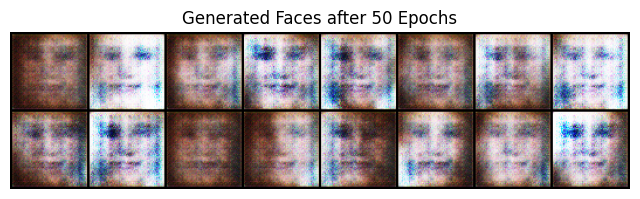

In [ ]:
import torchvision.utils as vutils
import numpy as np
# Put generator in evaluation mode
netG.eval()

with torch.no_grad():
  # Generate fake images from the fixed noise we saved earlier
  fake_output = netG(fixed_noise).detach().cpu()

# Plot the 16 generated faces in a grid
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Faces after 50 Epochs")
plt.imshow(
    np.transpose(
        vutils.make_grid(fake_output, padding=2, normalize=True), (1, 2, 0)
    )
)
plt.show()

In [ ]:
# 1. Grab 5,000 images instead of 100
test_dataset = ds["train"].select(range(5000))
print("Images selected for training:", len(test_dataset))

# 2. Re-initialize the dataset and dataloader with the new size
train_data = ProcessedUTKFace(test_dataset, transform=transform)
dataloader = DataLoader(train_data, batch_size=64, shuffle=True)  # Bumper batch size to 64 for speed

# 3. Re-initialize fresh models so they don't carry over the old 100-image weights
netG = Generator().to(device)
netD = Discriminator().to(device)

optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, 100, 1, 1, device=device)

# 4. Training loop with 100 epochs
num_epochs = 100
print("Starting Training Loop with 5,000 images...")

for epoch in range(num_epochs):
  for i, real_images in enumerate(dataloader):
    real_images = real_images.to(device)
    batch_size = real_images.size(0)

    # Train Discriminator
    netD.zero_grad()
    label_real = torch.full((batch_size, 1), 0.9, device=device)
    output_real = netD(real_images)
    loss_D_real = criterion(output_real, label_real)
    loss_D_real.backward()

    noise = torch.randn(batch_size, 100, 1, 1, device=device)
    fake_images = netG(noise)
    label_fake = torch.full((batch_size, 1), 0.0, device=device)
    output_fake = netD(fake_images.detach())
    loss_D_fake = criterion(output_fake, label_fake)
    loss_D_fake.backward()
    optimizerD.step()

    # Train Generator
    netG.zero_grad()
    label_gen = torch.full((batch_size, 1), 1.0, device=device)
    output = netD(fake_images)
    loss_G = criterion(output, label_gen)
    loss_G.backward()
    optimizerG.step()

  if (epoch + 1) % 10 == 0 or epoch == 0:
    print(
        f"Epoch [{epoch+1}/{num_epochs}] | Loss D: {(loss_D_real + loss_D_fake).item():.4f} | Loss G: {loss_G.item():.4f}"
    )

print("Training finished!")

Images selected for training: 5000
Starting Training Loop with 5,000 images...
Epoch [1/100] | Loss D: 0.5474 | Loss G: 9.0761
Epoch [10/100] | Loss D: 1.2382 | Loss G: 1.2386
Epoch [20/100] | Loss D: 0.4851 | Loss G: 5.3517
Epoch [30/100] | Loss D: 0.4636 | Loss G: 3.3883
Epoch [40/100] | Loss D: 0.3779 | Loss G: 5.7873
Epoch [50/100] | Loss D: 0.3600 | Loss G: 5.1545
Epoch [60/100] | Loss D: 0.3558 | Loss G: 6.2640
Epoch [70/100] | Loss D: 0.4839 | Loss G: 3.2857
Epoch [80/100] | Loss D: 0.7001 | Loss G: 2.6550
Epoch [90/100] | Loss D: 0.6746 | Loss G: 0.9624
Epoch [100/100] | Loss D: 0.4990 | Loss G: 2.8179
Training finished!


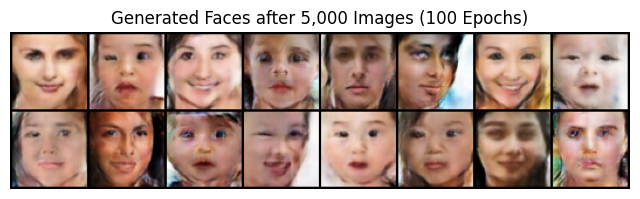

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

# 1. Switch generator to evaluation mode
netG.eval()

# 2. Generate a new batch of faces using your fixed noise
with torch.no_grad():
  test_fake_output = netG(fixed_noise).detach().cpu()

# 3. Plot them
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Faces after 5,000 Images (100 Epochs)")
plt.imshow(
    np.transpose(
        vutils.make_grid(test_fake_output, padding=2, normalize=True), (1, 2, 0)
    )
)
plt.show()

In [ ]:
# 1. Grab ALL images in the dataset (remove the .select range)
test_dataset = ds["train"]
print("Images selected for training (Full Dataset):", len(test_dataset))

# 2. Re-initialize the dataset and dataloader
train_data = ProcessedUTKFace(test_dataset, transform=transform)
dataloader = DataLoader(
    train_data, batch_size=64, shuffle=True, drop_last=True
)

# 3. Re-initialize fresh models
netG = Generator().to(device)
netD = Discriminator().to(device)

optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, 100, 1, 1, device=device)

# 4. Training loop with 150 epochs for high accuracy
num_epochs = 150
print("Starting Training Loop with ALL images...")

for epoch in range(num_epochs):
  for i, real_images in enumerate(dataloader):
    real_images = real_images.to(device)
    batch_size = real_images.size(0)

    # Train Discriminator
    netD.zero_grad()
    label_real = torch.full((batch_size, 1), 0.9, device=device)
    output_real = netD(real_images)
    loss_D_real = criterion(output_real, label_real)
    loss_D_real.backward()

    noise = torch.randn(batch_size, 100, 1, 1, device=device)
    fake_images = netG(noise)
    label_fake = torch.full((batch_size, 1), 0.0, device=device)
    output_fake = netD(fake_images.detach())
    loss_D_fake = criterion(output_fake, label_fake)
    loss_D_fake.backward()
    optimizerD.step()

    # Train Generator
    netG.zero_grad()
    label_gen = torch.full((batch_size, 1), 1.0, device=device)
    output = netD(fake_images)
    loss_G = criterion(output, label_gen)
    loss_G.backward()
    optimizerG.step()

  if (epoch + 1) % 10 == 0 or epoch == 0:
    print(
        f"Epoch [{epoch+1}/{num_epochs}] | Loss D: {(loss_D_real + loss_D_fake).item():.4f} | Loss G: {loss_G.item():.4f}"
    )

print("Training finished!")

Images selected for training (Full Dataset): 23705
Starting Training Loop with ALL images...
Epoch [1/150] | Loss D: 0.6338 | Loss G: 2.4449
Epoch [10/150] | Loss D: 0.3892 | Loss G: 4.4044
Epoch [20/150] | Loss D: 0.5023 | Loss G: 3.6779
Epoch [30/150] | Loss D: 0.4911 | Loss G: 3.7373
Epoch [40/150] | Loss D: 0.4129 | Loss G: 4.4213
Epoch [50/150] | Loss D: 0.5311 | Loss G: 3.1409
Epoch [60/150] | Loss D: 0.3586 | Loss G: 5.3249
Epoch [70/150] | Loss D: 0.5383 | Loss G: 2.8678
Epoch [80/150] | Loss D: 0.4075 | Loss G: 5.5761
Epoch [90/150] | Loss D: 0.3944 | Loss G: 5.2508
Epoch [100/150] | Loss D: 0.4541 | Loss G: 4.0888
Epoch [110/150] | Loss D: 0.3749 | Loss G: 4.4257
Epoch [120/150] | Loss D: 0.4204 | Loss G: 4.8056
Epoch [130/150] | Loss D: 0.4430 | Loss G: 4.3889
Epoch [140/150] | Loss D: 0.4155 | Loss G: 3.9482
Epoch [150/150] | Loss D: 0.3836 | Loss G: 5.4803
Training finished!


In [ ]:
#This is trained intensively over 150 epoches taking whole (100% ) of the dataset as training

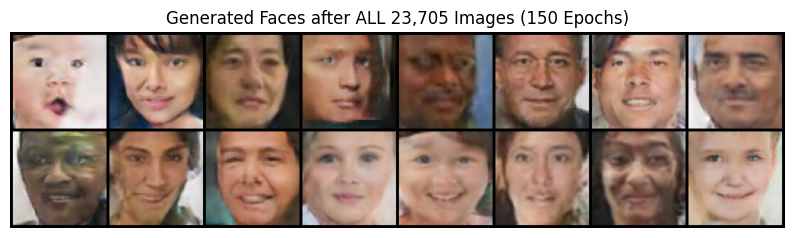

In [ ]:
# Plot the 16 generated faces in a grid
netG.eval()
with torch.no_grad():
  # We use the same fixed_noise so we can compare how much better it got
  test_fake_output = netG(fixed_noise).detach().cpu()

plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Generated Faces after ALL 23,705 Images (150 Epochs)")
plt.imshow(
    np.transpose(
        vutils.make_grid(test_fake_output, padding=2, normalize=True), (1, 2, 0)
    )
)
plt.show()

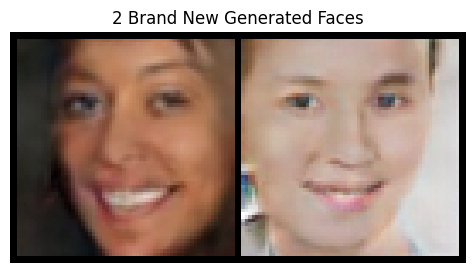

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.utils as vutils

# 1. Put model in evaluation mode
netG.eval()

# 2. Create BRAND NEW random noise for just 2 images
with torch.no_grad():
  new_noise = torch.randn(2, 100, 1, 1, device=device)
  new_faces = netG(new_noise).detach().cpu()

# 3. Plot the 2 new faces side-by-side cleanly
plt.figure(figsize=(6, 3))
plt.axis("off")
plt.title("2 Brand New Generated Faces")
plt.imshow(
    np.transpose(
        vutils.make_grid(new_faces, padding=2, normalize=True), (1, 2, 0)
    )
)
plt.show()

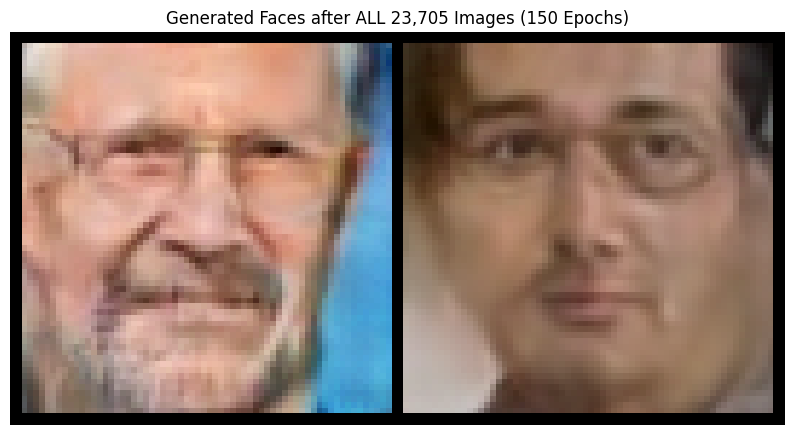

In [ ]:
# Plot the 16 generated faces in a grid
netG.eval()
with torch.no_grad():
  # We use the same fixed_noise so we can compare how much better it got
  new_noise = torch.randn(2, 100, 1, 1, device=device)
  new_faces = netG(new_noise).detach().cpu()
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Generated Faces after ALL 23,705 Images (150 Epochs)")
plt.imshow(
    np.transpose(
        vutils.make_grid(new_faces, padding=2, normalize=True), (1, 2, 0)
    )
)
plt.show()

In [ ]:
from google.colab import drive, files

# 1. save the model to Google Drive
drive.mount("/content/drive")

# 2. Save a copy permanently to your Google Drive folder
torch.save(netG.state_dict(), "/content/drive/MyDrive/utkface_generator_final.pth")
print("Saved to Google Drive!")

# 3. Download a copy to your local PC Downloads folder
files.documents("utkface_generator_final.pth")

Mounted at /content/drive
Saved to Google Drive!


AttributeError: module 'google.colab.files' has no attribute 'documents'

In [ ]:
torch.save(netG.state_dict(), "utkface_generator_final.pth")
files.download("utkface_generator_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

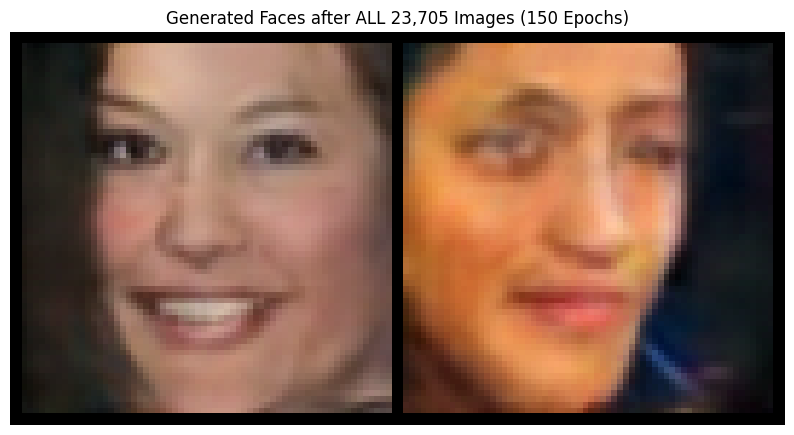

In [ ]:
# Plot the 16 generated faces in a grid
netG.eval()
with torch.no_grad():
  # We use the same fixed_noise so we can compare how much better it got
  new_noise = torch.randn(2, 100, 1, 1, device=device)
  new_faces = netG(new_noise).detach().cpu()
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Generated Faces after ALL 23,705 Images (150 Epochs)")
plt.imshow(
    np.transpose(
        vutils.make_grid(new_faces, padding=2, normalize=True), (1, 2, 0)
    )
)
plt.show()


In [ ]:
#Lets check the model size

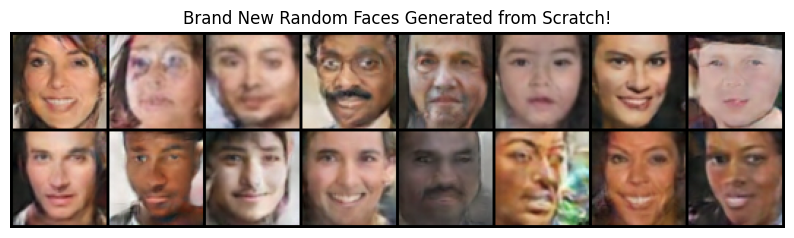

In [ ]:
netG.eval()
with torch.no_grad():
  # Generate BRAND NEW random noise (e.g., 16 faces of shape [16, 100, 1, 1])
  fresh_noise = torch.randn(16, 100, 1, 1, device=device)

  # Pass the fresh noise through the generator
  fresh_fake_output = netG(fresh_noise).detach().cpu()

# Plot the 16 newly generated faces in a grid
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Brand New Random Faces Generated from Scratch!")
plt.imshow(
    np.transpose(
        vutils.make_grid(fresh_fake_output, padding=2, normalize=True),
        (1, 2, 0),
    )
)
plt.show()

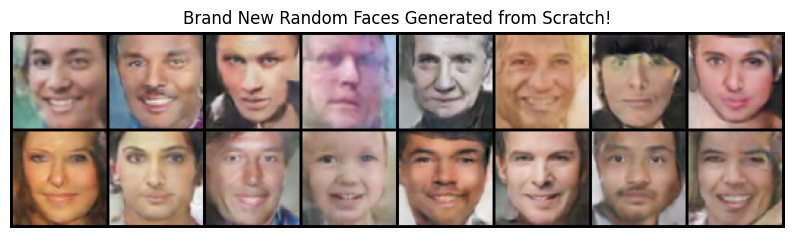

In [ ]:
netG.eval()
with torch.no_grad():
  # Generate BRAND NEW random noise (e.g., 16 faces of shape [16, 100, 1, 1])
  fresh_noise = torch.randn(16, 100, 1, 1, device=device)

  # Pass the fresh noise through the generator
  fresh_fake_output = netG(fresh_noise).detach().cpu()

# Plot the 16 newly generated faces in a grid
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Brand New Random Faces Generated from Scratch!")
plt.imshow(
    np.transpose(
        vutils.make_grid(fresh_fake_output, padding=2, normalize=True),
        (1, 2, 0),
    )
)
plt.show()

In [ ]:
import os

file_path = "utkface_generator_final.pth"

file_size_bytes = os.path.getsize(file_path)
file_size_mb = file_size_bytes / (1024 * 1024)

print(
    f"Model File Size: {file_size_mb:.2f} MB "
)

Model File Size: 13.66 MB 


In [ ]:
# Gooddye, hope you enjoy it! ✨
# Special thanks to the authors of the UTKFace dataset
#Dataset sourced via Hugging Face community repositories